<a href="https://colab.research.google.com/github/Mizharrrrrhidi1818/OutlierDetectionMethod-IsolationForest-LOF-DBSCAN/blob/main/notebooks/Outlier%20Detection%3A%20Space%20Shuttle%20Telemetry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **0. Load dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pyod.models.abod import ABOD
from sklearn.metrics import jaccard_score


df = pd.read_csv('train_shuttle.csv')
print("Dataset shape:", df.shape)
print(f"Columns: {df.columns.tolist()}")
print(f"Class Distribution:\n{df.iloc[:, -1].value_counts()}")

df.head()

Dataset shape: (43499, 10)
Columns: ['50', '21', '77', '0', '28', '0.1', '27', '48', '22', '2']
Class Distribution:
2
1    34108
4     6748
5     2458
3      132
2       36
7       11
6        6
Name: count, dtype: int64


,50,21,77,0,28,0.1,27,48,22,2
0,55,0,92,0,0,26,36,92,56,4
1,53,0,82,0,52,-5,29,30,2,1
2,37,0,76,0,28,18,40,48,8,1
3,37,0,79,0,34,-26,43,46,2,1
4,85,0,88,-4,6,1,3,83,80,5


We use dataset from train_shuttle. <br>
We have a dataset 43.499 rows and attributes 10 columns.

# **1. Preprocessing data and Exploration**

In [ ]:
from sklearn.preprocessing import StandardScaler

# a. Statistical description
print("\n a. Statictical description:  \n")
display(df.describe())

# b. Handling missing values
missing = df.isnull().sum()
print("\n b. Missing Values:  \n", missing)

# c. Handling Duplicates
dups = df.duplicated().sum()
print(f"\n c. Duplicates: {dups} ")
df = df.drop_duplicates().reset_index(drop=True)

# d. Feature Engineering & Scaling
feature_cols = df.columns[:-1]
target_col = df.columns[-1]

X = df[feature_cols].values
y_true = df[target_col].values

# Create binary labels: 0 for Normal (Class 1), 1 for Outlier (Classes 2-7)
y_binary = np.where(y_true == 1, 0, 1)

print(f"\n d. Feature Engineering:")
print(f"Normal instances (0): {np.sum(y_binary == 0)}")
print(f"Outlier instances (1): {np.sum(y_binary == 1)}")

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


 a. Statictical description:  



,50,21,77,0,28,0.1,27,48,22,2
count,43499.000000,43499.000000,43499.000000,43499.000000,43499.000000,43499.000000,43499.000000,43499.000000,43499.000000,43499.000000
mean,48.249707,-0.205614,85.341755,0.262742,34.528932,1.298306,37.074783,50.899929,13.964413,1.700522
std,12.252756,78.143602,8.908614,41.004603,21.703636,179.488823,13.135619,21.463492,25.648670,1.354663
min,27.000000,-4821.000000,21.000000,-3939.000000,-188.000000,-13839.000000,-48.000000,-353.000000,-356.000000,1.000000
25%,38.000000,0.000000,79.000000,0.000000,26.000000,-5.000000,31.000000,37.000000,0.000000,1.000000
50%,45.000000,0.000000,83.000000,0.000000,42.000000,0.000000,39.000000,44.000000,2.000000,1.000000
75%,55.000000,0.000000,89.000000,0.000000,46.000000,5.000000,42.000000,60.000000,14.000000,1.000000
max,126.000000,5075.000000,149.000000,3830.000000,436.000000,13148.000000,105.000000,270.000000,266.000000,7.000000



 b. Missing Values:  
 50     0
21     0
77     0
0      0
28     0
0.1    0
27     0
48     0
22     0
2      0
dtype: int64

 c. Duplicates: 0 

 d. Feature Engineering:
Normal instances (0): 34108
Outlier instances (1): 9391


The result from output preprocessing data: <br>

**a. Statistical Description** <br>
The dataset contains 43,499 instances with 10 features. The target variable (last column) ranges from 1 to 7, where class 1 represents normal operation and classes 2–7 represent faults. . The standard deviations vary widely across features.

**b. Missing Values** <br>
There are zero missing values across all 10 features, meaning the dataset is complete and requires no imputation.

**c. Duplicates** <br>
We don't have any duplicate rows, ensuring each instance is unique and independent.

**d. Feature Engineering** <br>
After converting the multi-class labels to binary, there are 34,108 normal instances (class 1 mapped to 0) and 9,391 outlier instances (classes 2–7 mapped to 1). This means approximately 21.6% of the data consists of outliers, which is a relatively high anomaly ratio compared to typical real-world datasets. This imbalance must be considered when selecting evaluation metrics; precision and recall for the minority class are more informative than overall accuracy

# **2. Implementation Detection Outliers method**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Apply Outlier Detection Methods

# Method 1: Isolation Forest
print("\nRunning Isolation Forest...")
# contamination should be close to the actual outlier ratio
outlier_ratio = np.sum(y_binary == 1) / len(y_binary)
print(f"Actual outlier ratio: {outlier_ratio:.4f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=outlier_ratio,
    random_state=42,
    n_jobs=-1
)
y_pred_iso = iso_forest.fit_predict(X_scaled)
# Isolation Forest returns -1 for outliers, 1 for inliers
y_pred_iso_binary = np.where(y_pred_iso == -1, 1, 0)

# Method 2: Local Outlier Factor (LOF)
print("Running Local Outlier Factor...")
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=outlier_ratio,
    novelty=False # Use fit_predict mode
)
y_pred_lof = lof.fit_predict(X_scaled)

y_pred_lof_binary = np.where(y_pred_lof == -1, 1, 0)

# Method 3: DBSCAN
print("Running DBSCAN...")
# DBSCAN doesn't take contamination directly. We tune eps and min_samples.
# For high-dimensional data, eps can be tricky. We'll use a heuristic.
dbscan = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1)
y_pred_dbscan = dbscan.fit_predict(X_scaled)
# DBSCAN returns -1 for noise (outliers), >=0 for cluster IDs
y_pred_dbscan_binary = np.where(y_pred_dbscan == -1, 1, 0)


Running Isolation Forest...
Actual outlier ratio: 0.2159
Running Local Outlier Factor...
Running DBSCAN...


In this section, I'm going to use 3 detection outlier method, then i wil give them paramaters each methods:
- **Isolation Forest**: n_estimators=100, contamination set to actual outlier ratio.
- **Local Outlier Factor (LOF)**: n_neighbors=20, contamination set to actual outlier ratio.
- **DBSCAN**: eps=0.5, min_samples=10.

# **3. Comparison Outlier Method**

In [ ]:
# Evaluate and Compare
def evaluate_method(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion Matrix:\n{cm}")

    return {'Method': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results = []
results.append(evaluate_method("Isolation Forest", y_binary, y_pred_iso_binary))
results.append(evaluate_method("Local Outlier Factor", y_binary, y_pred_lof_binary))
results.append(evaluate_method("DBSCAN", y_binary, y_pred_dbscan_binary))

# Create results DataFrame
results_df = pd.DataFrame(results)
print("\n=== Comparison Table ===")
print(results_df.to_string(index=False))




--- Isolation Forest ---
Accuracy: 0.8010
Precision: 0.5390
Recall: 0.5390
F1-Score: 0.5390
Confusion Matrix:
[[29779  4329]
 [ 4329  5062]]

--- Local Outlier Factor ---
Accuracy: 0.6680
Precision: 0.2312
Recall: 0.2312
F1-Score: 0.2312
Confusion Matrix:
[[26888  7220]
 [ 7220  2171]]

--- DBSCAN ---
Accuracy: 0.7840
Precision: 0.4909
Recall: 0.0144
F1-Score: 0.0279
Confusion Matrix:
[[33968   140]
 [ 9256   135]]

=== Comparison Table ===
              Method  Accuracy  Precision   Recall  F1-Score
    Isolation Forest  0.800961   0.539027 0.539027  0.539027
Local Outlier Factor  0.668038   0.231179 0.231179  0.231179
              DBSCAN  0.783995   0.490909 0.014375  0.027933


# **4. Visualisation Detection Outlier Method**

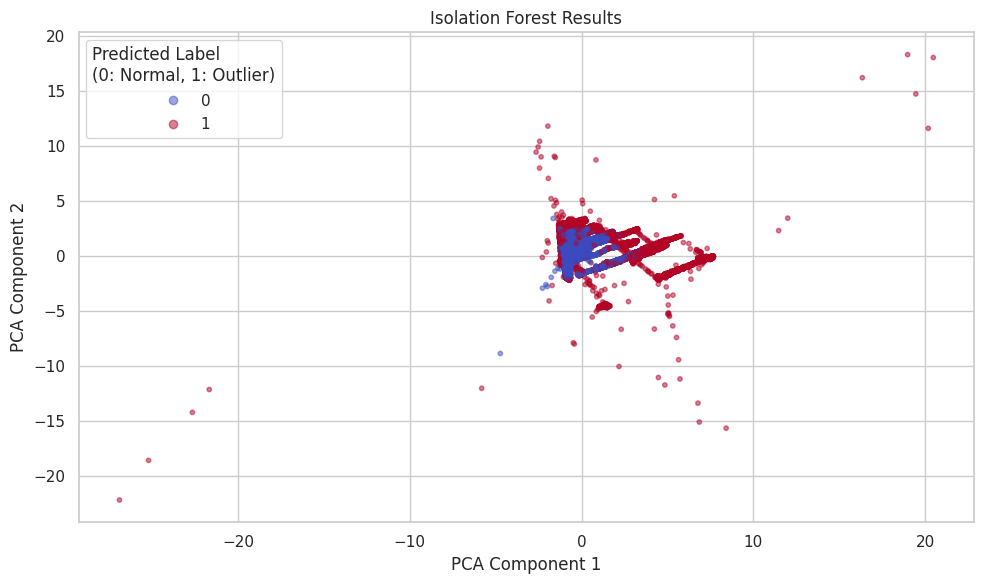

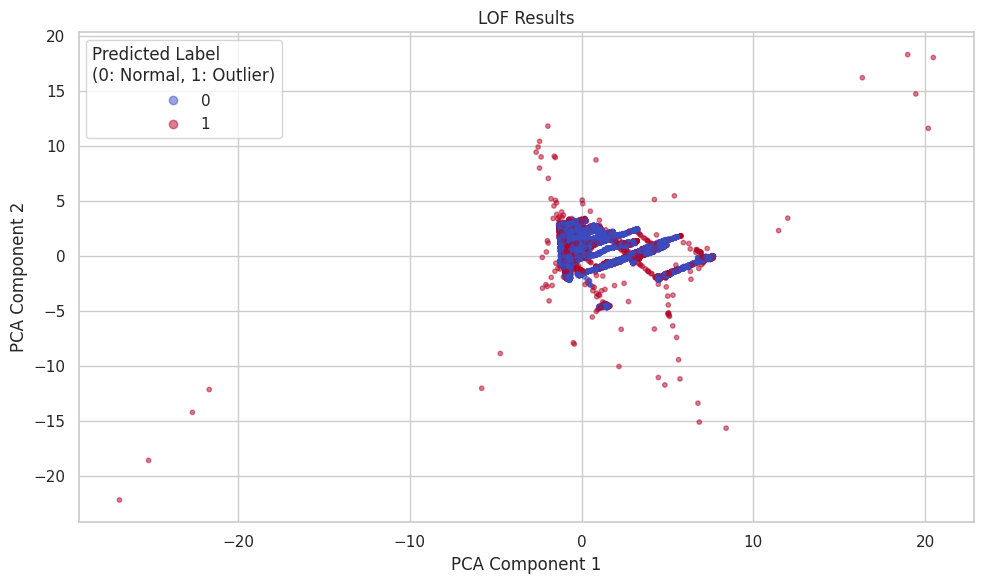

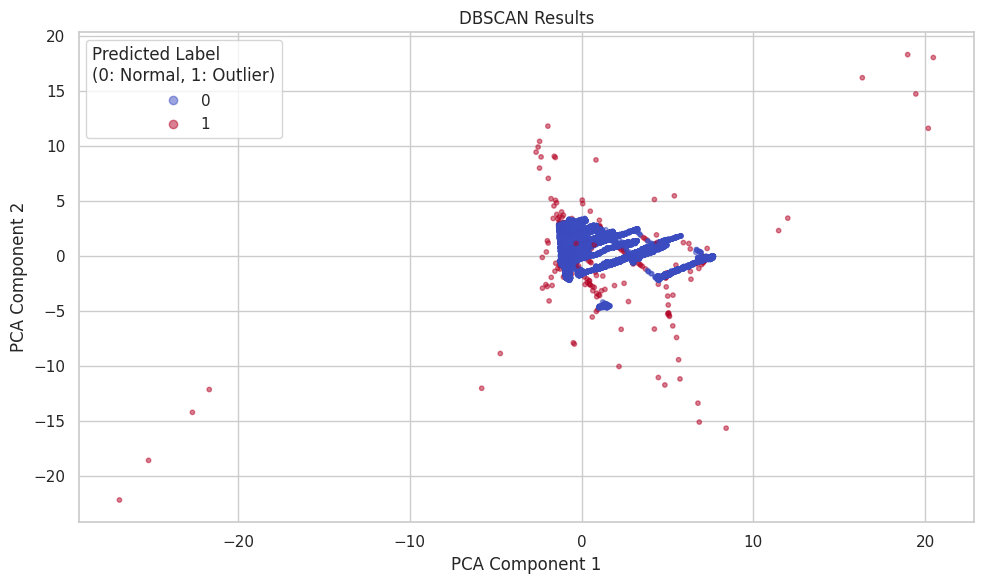


Agreement Rates:
IsoForest vs LOF: 0.6863
IsoForest vs DBSCAN: 0.7875
LOF vs DBSCAN: 0.7900


In [ ]:
# Reduce dimensions for visualization using PCA (first 2 components)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

def plot_outliers(title, y_pred_binary, X_pca):
    plt.figure()
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_binary, cmap='coolwarm', alpha=0.5, s=10)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend(*scatter.legend_elements(), title="Predicted Label\n(0: Normal, 1: Outlier)")
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').lower()}.png")
    plt.show()

plot_outliers("Isolation Forest Results", y_pred_iso_binary, X_pca)
plot_outliers("LOF Results", y_pred_lof_binary, X_pca)
plot_outliers("DBSCAN Results", y_pred_dbscan_binary, X_pca)

# Agreement Plot (Venn Diagram concept via heatmap of agreement)
# Let's check pairwise agreement
agreement_iso_lof = np.mean(y_pred_iso_binary == y_pred_lof_binary)
agreement_iso_db = np.mean(y_pred_iso_binary == y_pred_dbscan_binary)
agreement_lof_db = np.mean(y_pred_lof_binary == y_pred_dbscan_binary)

print(f"\nAgreement Rates:")
print(f"IsoForest vs LOF: {agreement_iso_lof:.4f}")
print(f"IsoForest vs DBSCAN: {agreement_iso_db:.4f}")
print(f"LOF vs DBSCAN: {agreement_lof_db:.4f}")

From my perspective, the visualization above portrays detection of outliers where we have definition 0 that is inlier or normal (blue dot), and 1 (red dot) is outlier.
- **Isolation Forest & LOF**: Both plots look nearly identical. They identify a dense central cluster as "Normal" (blue) and mark scattered points far from the center as "Outliers" (red). The red points form distinct arms or clusters, suggesting they are specific fault types rather than random noise.

- **DBSCAN**: This plot shows significantly more red points. It marks many points near the edge of the main blue cluster as outliers. It seems too sensitive to local density changes, labeling borderline normal data as anomalies.
Agreement/Disagreement:
High Agreement: Isolation Forest and LOF agree on almost all predictions. If one sees an outlier, the other usually does too.
Disagreement: DBSCAN disagrees with the other two. It flags many "borderline" points that Isolation Forest and LOF consider normal.
Reasoning:
The Shuttle dataset contains specific fault modes (classes 2-7) that are distinct from the normal state (class 1). Isolation Forest and LOF are better at finding these global deviations. DBSCAN struggles here because the "normal" class might have varying densities, causing it to mistakenly label valid edge cases as noise.


I guess **isolation Forest** is the best method for this dataset. It performs well even when outliers are rare. It detects the distinct fault patterns (the "arms" in the PCA plot) effectively without getting confused by the shape of the normal cluster. It is faster than LOF on large datasets like this one


# **5. Summary**

I suppose that isolation forest works best than other method. The Shuttle dataset contains global anomalies that are distinct from the main cluster. Isolation Forest detects these efficiently without relying on local density assumptions like LOF or strict distance thresholds like DBSCAN. For this specific data, tree-based isolation is superior to distance-based methods.
